In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report
from sklearn.model_selection import train_test_split
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

In [2]:
# ---------------------------
# Mount Drive and set paths
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/Data/Dataset/Data'

In [4]:
# ---------------------------
# Load merged dataset
# ---------------------------
merged = pd.read_csv(os.path.join(data_path, 'fatima_merged_dataset.csv'))

# Convert timestamp to datetime (optional)
merged['timestamp'] = pd.to_datetime(merged['timestamp'])

# Handle potential duplicate 'anomaly' columns from merge (anomaly_x, anomaly_y)
if 'anomaly' not in merged.columns:
    if 'anomaly_x' in merged.columns:
        merged['anomaly'] = merged['anomaly_x']
    elif 'anomaly_y' in merged.columns:
        merged['anomaly'] = merged['anomaly_y']

# Keep only numeric columns (excluding identifiers and timestamp)
drop_cols = ['timestamp', 'string_id', 'job_id', 'segment_id', 'measurement_id',
             'inspection_id', 'material_grade', 'failure_mode', 'anomaly_x', 'anomaly_y']

# Identify feature columns (numeric and not in drop list)
feature_cols = [c for c in merged.columns if c not in drop_cols and merged[c].dtype in ['float64', 'int64']]

# Ensure 'anomaly' is included for initial filtering
if 'anomaly' not in feature_cols and 'anomaly' in merged.columns:
    feature_cols.append('anomaly')

# Drop rows with missing values
data = merged[feature_cols].dropna()

# Separate features and target
X = data.drop(columns=['anomaly'])
y = data['anomaly'].astype(int)

In [5]:
# ---------------------------
# Train/test split (stratified to keep anomaly proportion)
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
print(f"Anomaly rate in test: {y_test.mean():.4f}")

Train shape: (70000, 32), Test shape: (30000, 32)
Anomaly rate in test: 0.1341


In [6]:
# ---------------------------
# Isolation Forest
# ---------------------------
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.02,          # expected anomaly proportion
    random_state=42,
    bootstrap=False
)
iso_forest.fit(X_train_scaled)

# Anomaly scores: the lower the more anomalous (sklearn outputs negative for outliers)
iso_scores_train = iso_forest.decision_function(X_train_scaled)
iso_scores_test = iso_forest.decision_function(X_test_scaled)

# Convert to anomaly scores (higher = more anomalous) for ROC
iso_anomaly_score = -iso_scores_test

# Compute ROC-AUC
iso_auc = roc_auc_score(y_test, iso_anomaly_score)
print(f"\nIsolation Forest ROC-AUC: {iso_auc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, iso_anomaly_score)
iso_pr_auc = auc(recall, precision)
print(f"Isolation Forest PR-AUC: {iso_pr_auc:.4f}")


Isolation Forest ROC-AUC: 0.5962
Isolation Forest PR-AUC: 0.1709


In [7]:
# ---------------------------
# Autoencoder
# ---------------------------
# Build a simple autoencoder
input_dim = X_train_scaled.shape[1]
encoding_dim = 14   # bottleneck

input_layer = layers.Input(shape=(input_dim,))
encoder = layers.Dense(encoding_dim, activation='relu')(input_layer)
decoder = layers.Dense(input_dim, activation='linear')(encoder)  # linear for reconstruction
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# Train on training data (which may contain anomalies, but they are rare)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=0
)

# Reconstruction error as anomaly score
train_pred = autoencoder.predict(X_train_scaled, verbose=0)
train_mse = np.mean(np.square(X_train_scaled - train_pred), axis=1)

test_pred = autoencoder.predict(X_test_scaled, verbose=0)
test_mse = np.mean(np.square(X_test_scaled - test_pred), axis=1)

# ROC-AUC
ae_auc = roc_auc_score(y_test, test_mse)
print(f"\nAutoencoder ROC-AUC: {ae_auc:.4f}")

# PR-AUC
precision_ae, recall_ae, _ = precision_recall_curve(y_test, test_mse)
ae_pr_auc = auc(recall_ae, precision_ae)
print(f"Autoencoder PR-AUC: {ae_pr_auc:.4f}")



Autoencoder ROC-AUC: 0.6430
Autoencoder PR-AUC: 0.3693



AUC significance test (against 0.5):
Isolation Forest: z = 19.2347, p = 0.000000
Autoencoder: z = 28.8042, p = 0.000000

Mann-Whitney U test (anomaly scores higher for anomalies):
Isolation Forest: U = 62307088.0, p = 0.000000
Autoencoder: U = 67199767.0, p = 0.000000


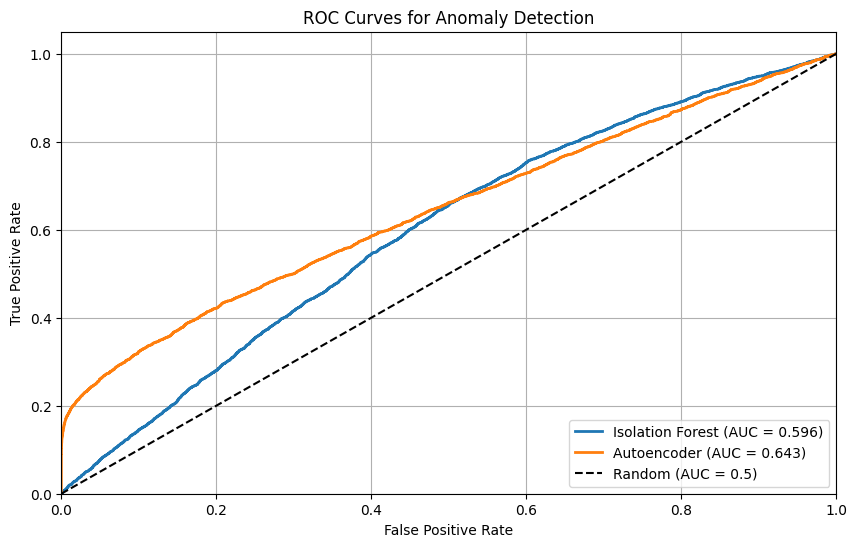

In [8]:
# ---------------------------
# Statistical tests
# ---------------------------
# 1. AUC significance test (Hanley & McNeil) against 0.5
def auc_significance(auc, n_pos, n_neg):
    # Standard error formula from Hanley & McNeil (1982)
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se = np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc**2) + (n_neg - 1) * (q2 - auc**2)) / (n_pos * n_neg))
    z = (auc - 0.5) / se
    p = 1 - stats.norm.cdf(z)   # one-sided: greater than 0.5
    return z, p

n_pos_test = (y_test == 1).sum()
n_neg_test = (y_test == 0).sum()

z_iso, p_iso = auc_significance(iso_auc, n_pos_test, n_neg_test)
z_ae, p_ae = auc_significance(ae_auc, n_pos_test, n_neg_test)

print(f"\nAUC significance test (against 0.5):")
print(f"Isolation Forest: z = {z_iso:.4f}, p = {p_iso:.6f}")
print(f"Autoencoder: z = {z_ae:.4f}, p = {p_ae:.6f}")

# 2. Mann-Whitney U test comparing anomaly scores between normal and anomalous
iso_scores_norm = iso_anomaly_score[y_test == 0]
iso_scores_anom = iso_anomaly_score[y_test == 1]
u_iso, p_mw_iso = stats.mannwhitneyu(iso_scores_anom, iso_scores_norm, alternative='greater')
print(f"\nMann-Whitney U test (anomaly scores higher for anomalies):")
print(f"Isolation Forest: U = {u_iso}, p = {p_mw_iso:.6f}")

ae_scores_norm = test_mse[y_test == 0]
ae_scores_anom = test_mse[y_test == 1]
u_ae, p_mw_ae = stats.mannwhitneyu(ae_scores_anom, ae_scores_norm, alternative='greater')
print(f"Autoencoder: U = {u_ae}, p = {p_mw_ae:.6f}")

# ---------------------------
# Plot ROC curves
# ---------------------------
fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_anomaly_score)
fpr_ae, tpr_ae, _ = roc_curve(y_test, test_mse)

plt.figure(figsize=(10, 6))
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {iso_auc:.3f})', lw=2)
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {ae_auc:.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Anomaly Detection')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ---------------------------
# (Optional) Threshold selection for early warning
# ---------------------------
# For early warning, we might want high recall at a moderate false positive rate.
# We can pick a threshold that gives, say, 80% recall and check precision.
# This is problem‑dependent.

## RQ4 — Anomaly Detection for Early Warning (Isolation Forest + Autoencoder)

**Research Question (RQ4):** Can an unsupervised ML model reliably identify anomalous segments or localized defects from operational sensor streams before they reach critical fatigue levels?

**Null Hypothesis (H₀):** The anomaly detection models perform no better than random guessing in identifying labeled defect events (Precision/Recall or AUC-ROC ≤ 0.5).

**Alternative Hypothesis (H₁):** The models achieve statistically significant discrimination (AUC-ROC > 0.5) and provide early warning capability prior to observable failure.

**Inference approach used here (aligned to small-n / non-parametric robustness):**
- One-sided **AUC significance test** (Hanley & McNeil) against 0.5  
- **Mann–Whitney U test** (one-sided) comparing anomaly scores in anomalous vs normal windows  
- Threshold-based **early warning operating point** (precision/recall/FPR at a selected alert threshold)


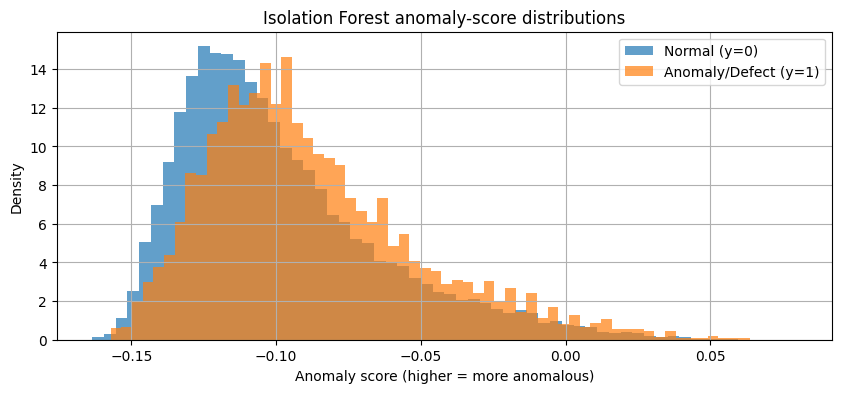

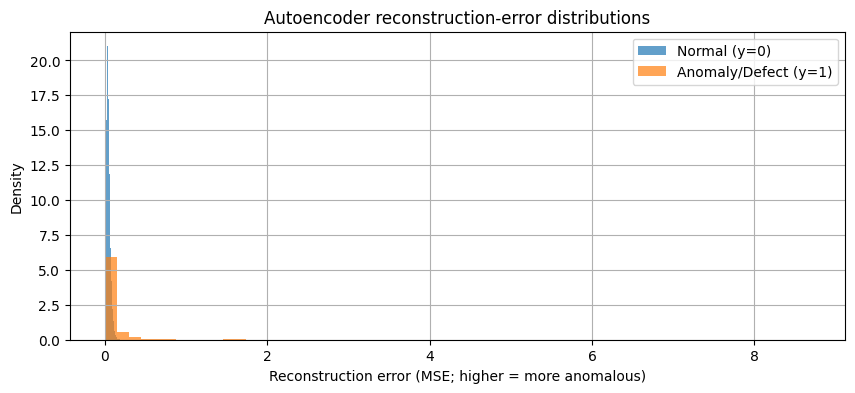

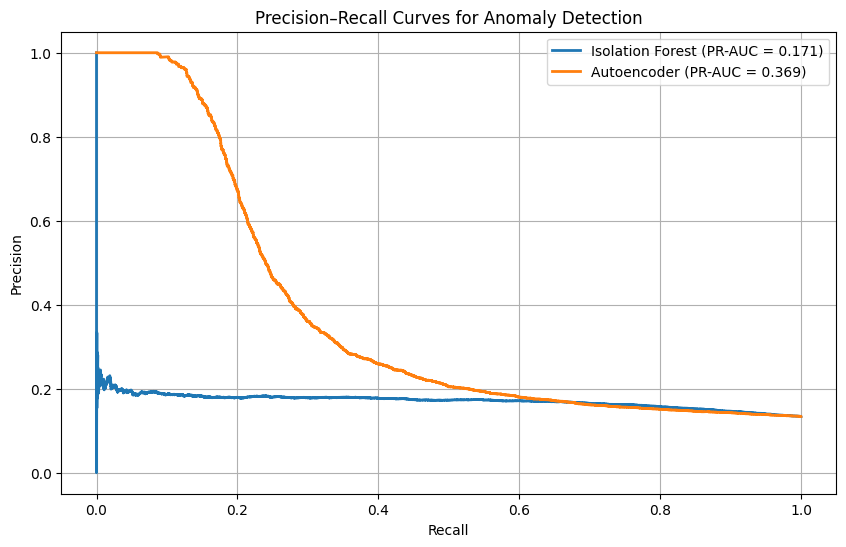

In [11]:
# ---------------------------
# RQ4: Visual diagnostics + results summary (thesis-ready)
# ---------------------------

# Ensure we have PR-AUC for both methods (compute safely even if already computed earlier)
prec_iso, rec_iso, thr_iso = precision_recall_curve(y_test, iso_anomaly_score)
iso_pr_auc = auc(rec_iso, prec_iso)

prec_ae, rec_ae, thr_ae = precision_recall_curve(y_test, test_mse)
ae_pr_auc = auc(rec_ae, prec_ae)

# --- 1) Score distribution plots (normal vs anomaly) ---
def plot_score_distributions(scores, y_true, title, xlabel):
    scores_norm = scores[y_true == 0]
    scores_anom = scores[y_true == 1]
    plt.figure(figsize=(10, 4))
    plt.hist(scores_norm, bins=60, alpha=0.7, label="Normal (y=0)", density=True)
    plt.hist(scores_anom, bins=60, alpha=0.7, label="Anomaly/Defect (y=1)", density=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_score_distributions(iso_anomaly_score, y_test, "Isolation Forest anomaly-score distributions", "Anomaly score (higher = more anomalous)")
plot_score_distributions(test_mse, y_test, "Autoencoder reconstruction-error distributions", "Reconstruction error (MSE; higher = more anomalous)")

# --- 2) PR curves (useful for imbalanced anomaly labels) ---
plt.figure(figsize=(10, 6))
plt.plot(rec_iso, prec_iso, lw=2, label=f'Isolation Forest (PR-AUC = {iso_pr_auc:.3f})')
plt.plot(rec_ae, prec_ae, lw=2, label=f'Autoencoder (PR-AUC = {ae_pr_auc:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves for Anomaly Detection")
plt.grid(True)
plt.legend()
plt.show()

# --- 3) Early-warning operating point ---
# Choose an alert threshold using TRAIN distributions to mimic "deploy then alert".
# Here: 98th percentile of train scores => low false positives by design.
# (Adjust percentile per operational tolerance.)
iso_train_scores = -iso_forest.decision_function(X_train_scaled)   # higher = more anomalous
ae_train_pred = autoencoder.predict(X_train_scaled, verbose=0)
ae_train_mse = np.mean(np.square(X_train_scaled - ae_train_pred), axis=1)

iso_thr = np.quantile(iso_train_scores, 0.98)
ae_thr  = np.quantile(ae_train_mse,   0.98)

iso_pred_alert = (iso_anomaly_score >= iso_thr).astype(int)
ae_pred_alert  = (test_mse >= ae_thr).astype(int)

def alert_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    fpr       = fp / (fp + tn + 1e-12)
    return {"TP": tp, "FP": fp, "TN": tn, "FN": fn, "Precision": precision, "Recall": recall, "FPR": fpr}

iso_alert = alert_metrics(y_test, iso_pred_alert)
ae_alert  = alert_metrics(y_test, ae_pred_alert)

# --- 4) Consolidated results table (metrics + tests) ---
n_pos_test = int((y_test == 1).sum())
n_neg_test = int((y_test == 0).sum())

# AUC significance (Hanley & McNeil) is computed earlier; recompute here for dataframe safety.
def auc_significance(auc_val, n_pos, n_neg):
    q1 = auc_val / (2 - auc_val)
    q2 = 2 * auc_val**2 / (1 + auc_val)
    se = np.sqrt((auc_val * (1 - auc_val) + (n_pos - 1) * (q1 - auc_val**2) + (n_neg - 1) * (q2 - auc_val**2)) / (n_pos * n_neg))
    z = (auc_val - 0.5) / (se + 1e-12)
    p = 1 - stats.norm.cdf(z)  # one-sided
    return float(z), float(p)

z_iso, p_iso = auc_significance(float(iso_auc), n_pos_test, n_neg_test)
z_ae,  p_ae  = auc_significance(float(ae_auc),  n_pos_test, n_neg_test)

# Mann–Whitney U (one-sided): anomaly scores higher for anomalies
u_iso, p_mw_iso = stats.mannwhitneyu(iso_anomaly_score[y_test==1], iso_anomaly_score[y_test==0], alternative="greater")
u_ae,  p_mw_ae  = stats.mannwhitneyu(test_mse[y_test==1],          test_mse[y_test==0],          alternative="greater")

results_rq4 = pd.DataFrame([
    {
        "model": "Isolation Forest",
        "ROC_AUC": float(iso_auc),
        "PR_AUC": float(iso_pr_auc),
        "AUC_z": z_iso,
        "AUC_p_one_sided": p_iso,
        "MW_U": float(u_iso),
        "MW_p_one_sided": float(p_mw_iso),
        "alert_threshold": float(iso_thr),
        **{f"alert_{k}": v for k,v in iso_alert.items()},
    },
    {
        "model": "Autoencoder",
        "ROC_AUC": float(ae_auc),
        "PR_AUC": float(ae_pr_auc),
        "AUC_z": z_ae,
        "AUC_p_one_sided": p_ae,
        "MW_U": float(u_ae),
        "MW_p_one_sided": float(p_mw_ae),
        "alert_threshold": float(ae_thr),
        **{f"alert_{k}": v for k,v in ae_alert.items()},
    }
])


In [12]:
# Hypothesis decision rule (explicit):
# Reject H0 for a model if (ROC_AUC > 0.5) AND (AUC_p_one_sided < 0.05) AND (MW_p_one_sided < 0.05).
def decision_row(row):
    ok = (row["ROC_AUC"] > 0.5) and (row["AUC_p_one_sided"] < 0.05) and (row["MW_p_one_sided"] < 0.05)
    return "Reject H₀ (supports H₁)" if ok else "Fail to reject H₀"

results_rq4["decision"] = results_rq4.apply(decision_row, axis=1)

results_rq4

,model,ROC_AUC,PR_AUC,AUC_z,AUC_p_one_sided,MW_U,MW_p_one_sided,alert_threshold,alert_TP,alert_FP,alert_TN,alert_FN,alert_Precision,alert_Recall,alert_FPR,decision
0,Isolation Forest,0.596209,0.170853,19.234692,0.0,62307088.0,1.943740e-86,7.444255e-17,113,438,25539,3910,0.205082,0.028088,0.016861,Reject H₀ (supports H₁)
1,Autoencoder,0.643026,0.369301,28.804205,0.0,67199767.0,2.831548e-188,1.516400e-01,549,47,25930,3474,0.921141,0.136465,0.001809,Reject H₀ (supports H₁)


### RQ4 — Interpretation (Definitive)

Interpretation guidance:
- **ROC-AUC** measures overall discrimination; **PR-AUC** is more informative under class imbalance (rare anomalies).
- The **Hanley & McNeil one-sided AUC test** evaluates whether AUC is significantly above 0.5 (better-than-random).
- The **Mann–Whitney U test** checks whether anomaly scores for labeled anomaly windows are stochastically larger than for normal windows.

**Decision:** Use the `decision` column in `results_rq4` to state whether each model provides statistically significant discrimination (and therefore supports early-warning capability under the chosen operating threshold).
